## Purpose
This notebook constructs the Aggressive Growth, Balanced Growth, and Resilient Growth portfolios using the strategic asset allocations defined in the the Portfolio Construction Report. Daily portfolio returns are calculated from the cleaned asset returns prepared in Notebook 1 and saved for the risk and performance analyses that follow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv(
    "returns_daily.csv",
    index_col=0,
    parse_dates=True
)

## Define Weights

### Historical Proxy Implementation

The intended portfolio allocations described in the Investment Policy Statement use VXUS for international equity exposure and SGOV for short-term Treasury exposure. Because neither ETF has enough history for the full backtest period, VEU and BIL are used as historical proxies.

The portfolio weights themselves are unchanged; only the ETFs used to represent those asset classes in the historical analysis are different. VXUS and SGOV remain the intended implementation ETFs, while VEU and BIL allow the portfolios to be evaluated over a longer common sample.

In [2]:
weights_aggressive = {
    "VTI": 0.55,
    "VEU": 0.20, # Historical proxy for VXUS
    "VWO": 0.10,
    "BND": 0.05,
    "GLD": 0.05,
    "BIL": 0.05 # Historical proxy for SGOV
}

weights_balanced = {
    "VTI": 0.40,
    "VEU": 0.15, # Historical proxy for VXUS
    "VWO": 0.10,
    "BND": 0.25,
    "GLD": 0.05,
    "BIL": 0.05 # Historical proxy for SGOV
}

weights_resilient = {
    "VTI": 0.25,
    "VEU": 0.10, # Historical proxy for VXUS
    "VWO": 0.05,
    "BND": 0.45,
    "GLD": 0.10,
    "BIL": 0.05 # Historical proxy for SGOV
}

portfolio_weights = pd.DataFrame({
    "Aggressive": weights_aggressive,
    "Balanced": weights_balanced,
    "Resilient": weights_resilient
})

# Confirm that each portfolio is fully invested
weight_sums = portfolio_weights.sum(axis=0)

if not np.allclose(weight_sums.values, 1.0):
    raise ValueError("One or more portfolio weight sets do not sum to 100%.")

display(
    portfolio_weights.style
    .format("{:.0%}")
    .set_caption("Strategic Portfolio Weights")
)


,Aggressive,Balanced,Resilient
VTI,55%,40%,25%
VEU,20%,15%,10%
VWO,10%,10%,5%
BND,5%,25%,45%
GLD,5%,5%,10%
BIL,5%,5%,5%


In [3]:
#Save to csv
portfolio_weights.to_csv(
    "portfolio_weights.csv"
)

## Portfolio Return Calculation

Daily portfolio returns are calculated as the weighted sum of the underlying asset returns:

$$
R_{p,t} = \sum_{i=1}^{n} w_iR_{i,t}
$$

where $w_i$ is the strategic weight assigned to asset $i$ and $R_{i,t}$ is that asset's daily return.

The same target weights are applied each day throughout the historical sample. This creates a constant-weight historical simulation, which is equivalent to assuming that the portfolios are rebalanced back to their strategic targets daily. The assumption is used to isolate the effect of strategic asset allocation and provide a consistent comparison across the three portfolios.

This is a simplifying backtesting assumption rather than the practical rebalancing policy developed later in the project. Transaction costs, taxes, and trading frictions associated with maintaining constant weights are not modeled.

In [4]:
# Confirm that all required assets are available
required_assets = portfolio_weights.index.tolist()

missing_assets = [
    asset for asset in required_assets
    if asset not in returns.columns
]

if missing_assets:
    raise ValueError(
        f"Missing required return series: {missing_assets}"
    )

# Calculate daily portfolio returns
portfolio_returns = (
    returns[required_assets]
    .dot(portfolio_weights)
)

display(portfolio_returns.head())

,Aggressive,Balanced,Resilient
Date,,,
2007-05-31,0.002857,0.002203,0.001999
2007-06-01,0.007015,0.005458,0.003460
2007-06-04,0.001120,0.000994,0.001095
2007-06-05,-0.004741,-0.004004,-0.003120
2007-06-06,-0.009978,-0.007555,-0.004277


In [5]:
print(
    f"Portfolio return sample: "
    f"{portfolio_returns.index.min().date()} "
    f"to {portfolio_returns.index.max().date()}"
)

print(f"Trading-day observations: {len(portfolio_returns):,}")

Portfolio return sample: 2007-05-31 to 2026-09-18
Trading-day observations: 4,857


In [6]:
portfolio_returns.to_csv("portfolio_returns.csv")

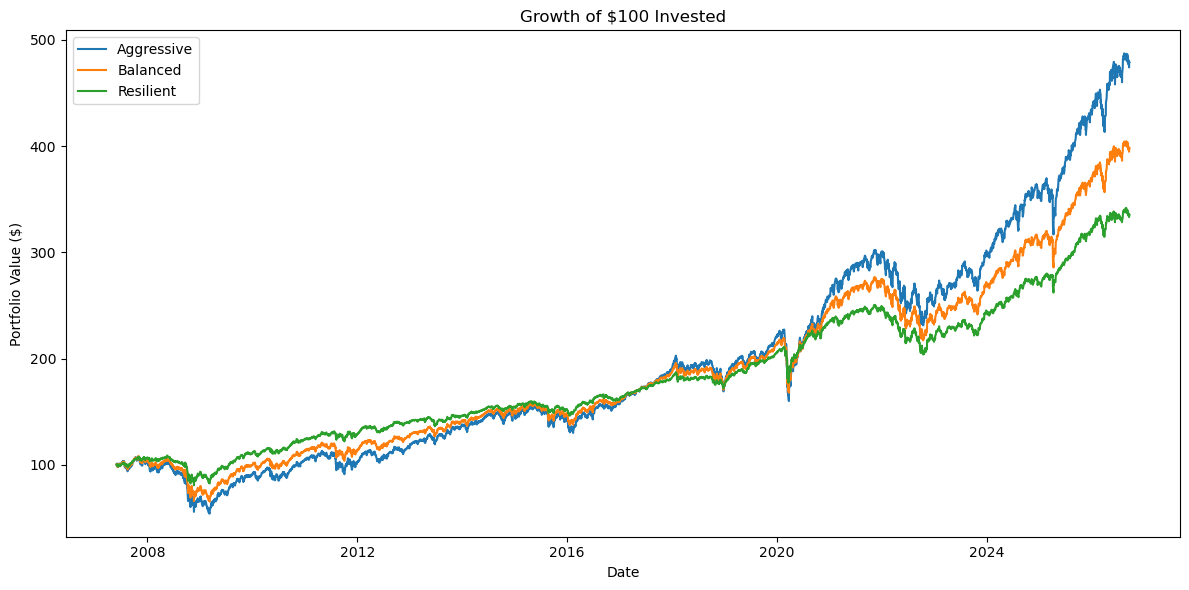

In [7]:
growth = (1 + portfolio_returns).cumprod() * 100

plt.figure(figsize=(12, 6))

for column in growth.columns:
    plt.plot(
        growth.index,
        growth[column],
        label=column
    )

plt.title("Growth of $100 Invested")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
#Ending value of $100 invested 
final_growth = growth.iloc[-1].to_frame(
    name="Ending Value"
)

display(
    final_growth.style
    .format({"Ending Value": "${:,.2f}"})
    .set_caption("Ending Value of $100 Investment")
)

,Ending Value
Aggressive,$479.02
Balanced,$398.11
Resilient,$335.59


In [9]:
from IPython.display import display, Markdown

start_date = portfolio_returns.index.min().strftime("%B %Y")
end_date = portfolio_returns.index.max().strftime("%B %Y")

ending_values = growth.iloc[-1]

display(Markdown(
    f"""
**Interpretation**

The cumulative-growth chart compares how a hypothetical $100 investment would have evolved across the three strategic allocations from **{start_date} through {end_date}** under the constant-weight backtesting assumption.

The Aggressive portfolio produced the greatest cumulative growth over the sample, followed by the Balanced and Resilient portfolios. The chart also shows that the additional growth came with larger fluctuations during major market declines, while the more defensive allocations experienced less pronounced changes in portfolio value.

This chart provides an initial view of the trade-off between growth and portfolio stability. The next notebook evaluates those differences more formally using volatility, risk-adjusted performance, drawdown, Value at Risk, Expected Shortfall, and other portfolio-risk measures.
"""
))


**Interpretation**

The cumulative-growth chart compares how a hypothetical $100 investment would have evolved across the three strategic allocations from **May 2007 through September 2026** under the constant-weight backtesting assumption.

The Aggressive portfolio produced the greatest cumulative growth over the sample, followed by the Balanced and Resilient portfolios. The chart also shows that the additional growth came with larger fluctuations during major market declines, while the more defensive allocations experienced less pronounced changes in portfolio value.

This chart provides an initial view of the trade-off between growth and portfolio stability. The next notebook evaluates those differences more formally using volatility, risk-adjusted performance, drawdown, Value at Risk, Expected Shortfall, and other portfolio-risk measures.
